In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
ts = pd.read_csv("Microsoft_Stock.csv")
ts.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


In [3]:
ts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1511 entries, 0 to 1510
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1511 non-null   object 
 1   Open    1511 non-null   float64
 2   High    1511 non-null   float64
 3   Low     1511 non-null   float64
 4   Close   1511 non-null   float64
 5   Volume  1511 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 71.0+ KB


In [4]:
ts.describe()

,Open,High,Low,Close,Volume
count,1511.000000,1511.000000,1511.000000,1511.000000,1.511000e+03
mean,107.385976,108.437472,106.294533,107.422091,3.019863e+07
std,56.691333,57.382276,55.977155,56.702299,1.425266e+07
min,40.340000,40.740000,39.720000,40.290000,1.016120e+05
25%,57.860000,58.060000,57.420000,57.855000,2.136213e+07
50%,93.990000,95.100000,92.920000,93.860000,2.662962e+07
75%,139.440000,140.325000,137.825000,138.965000,3.431962e+07
max,245.030000,246.130000,242.920000,244.990000,1.352271e+08


In [5]:
ts.shape

(1511, 6)

In [6]:
ts.columns

Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume'], dtype='object')

In [7]:
ts.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [8]:
ts.duplicated().sum()

np.int64(0)

In [9]:
ts.index = pd.to_datetime(ts['Date'])
ts = ts.drop(['Date'], axis = 1)

In [10]:
ts.head(5)

,Open,High,Low,Close,Volume
Date,,,,,
2015-04-01 16:00:00,40.60,40.76,40.31,40.72,36865322
2015-04-02 16:00:00,40.66,40.74,40.12,40.29,37487476
2015-04-06 16:00:00,40.34,41.78,40.18,41.55,39223692
2015-04-07 16:00:00,41.61,41.91,41.31,41.53,28809375
2015-04-08 16:00:00,41.48,41.69,41.04,41.42,24753438


<Axes: xlabel='Date'>

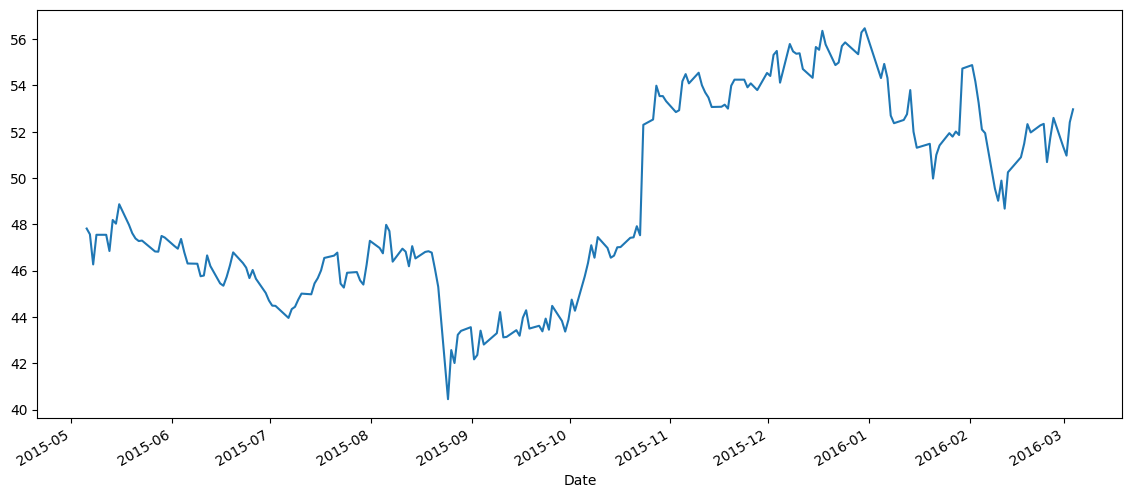

In [11]:
ts1 = ts[23:233]
ts1['Open'].plot(figsize = (14, 6))

# What the graph tells us
 
##  📈 Overall Trend
1.  The stock starts around 47–48 in May 2015.
2. It ends around 53 in March 2016.
3.  Overall, the stock shows an upward trend, meaning Microsoft's value increased during this period.
##  📉 Downward Phase (May–September 2015)
1. Prices gradually decline from about 48 to 41.
2. The sharp drop around late August/early September indicates a significant market correction or company-related event.
## 📈 Recovery Phase (September–November 2015) 
1. After reaching its lowest point (~40.5), the stock recovers steadily.
2. A noticeable jump occurs around late October/early November, suggesting positive news, earnings, or market sentiment.
## 📊 Strong Growth Period (November 2015–January 2016)
1. The stock remains mostly between 53–56.
2. It reaches its highest value around 56.5 in January 2016.
## 📉 Short-Term Volatility (January–March 2016)
1. Prices fluctuate between 49–55.
2. Despite these fluctuations, the stock stays well above its September lows.
3. Key Insights for Your Project
###  Trend: Upward (good for forecasting).
###  Seasonality: Not obvious from this single plot.
###  Volatility: Moderate, especially around Aug–Sep 2015 and Jan–Feb 2016.
### Potential Outliers: Sharp drop in September and sharp rise in November.

#### Microsoft stock prices exhibited an overall upward trend during the observed period. The stock experienced a significant decline in September 2015, followed by a strong recovery and sustained growth until January 2016. Although short-term fluctuations were present, the long-term trend remained positive, indicating increasing investor confidence in the company

<Axes: xlabel='Date'>

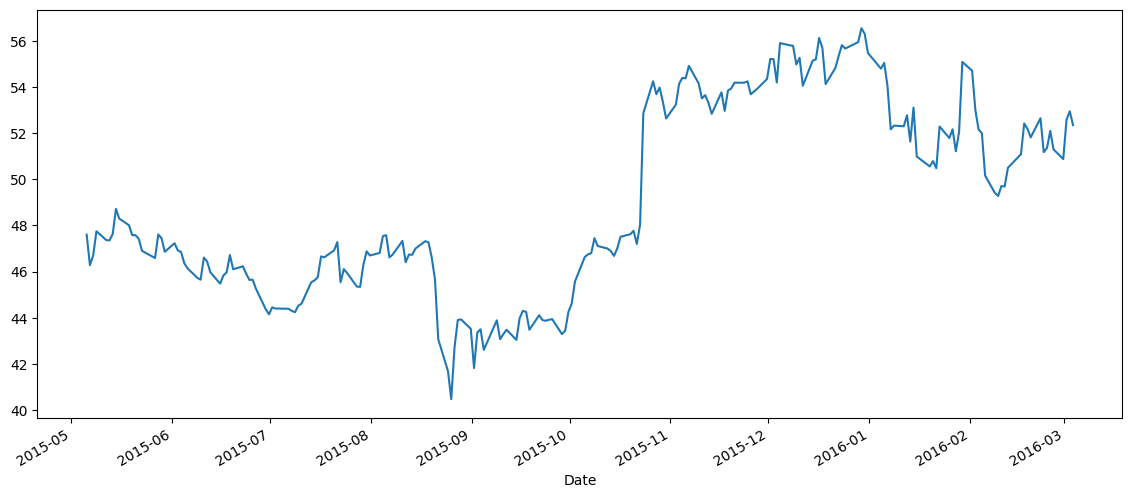

In [12]:
ts1 = ts[23:233]
ts1['Close'].plot(figsize = (14, 6))

#### The Microsoft stock price exhibits an overall upward trend with periods of short-term volatility. A major decline occurred in August 2015, followed by a strong recovery and sustained growth until January 2016. The stock reached a peak near 56.5 before undergoing a correction and stabilizing around 52–53. These patterns suggest the presence of a long-term bullish trend with temporary market fluctuations.

<Axes: xlabel='Date'>

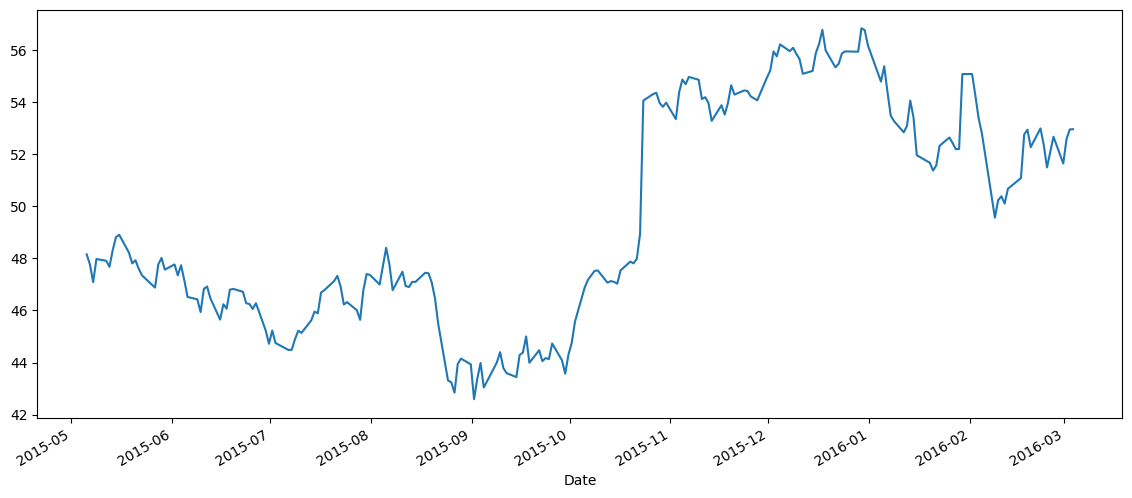

In [13]:
ts1 = ts[23:233]
ts1['High'].plot(figsize = (14, 6))

##### The daily high prices of Microsoft stock exhibited a clear upward trend over the observed period. After reaching a low near 43 in September 2015, the stock experienced significant growth and attained a peak close to 57 in January 2016. Although a short-term correction followed, the stock remained above its earlier lows, indicating overall positive market performance.

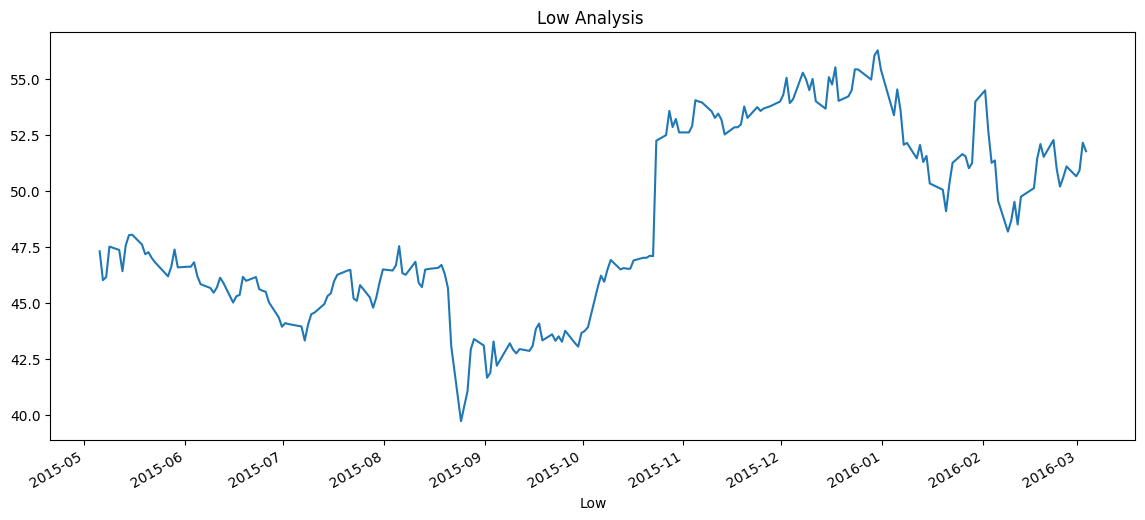

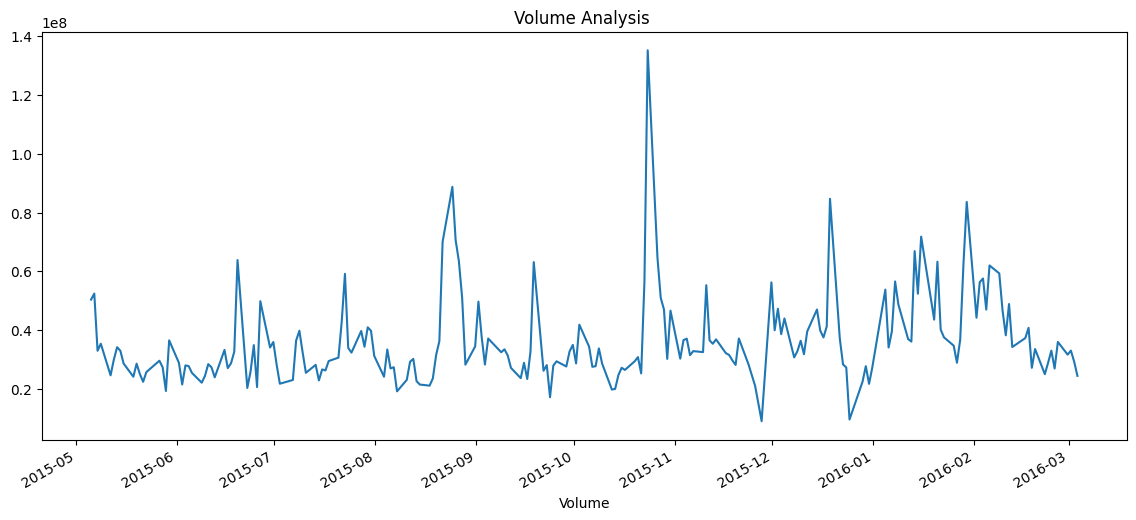

In [14]:
features = ['Low', 'Volume']

for feature in features:
    ts1[feature].plot(figsize = (14, 6))
    plt.title(f'{feature} Analysis ')
    plt.xlabel(f'{feature}')
    plt.show()

np.float64(0.8273771005260597)

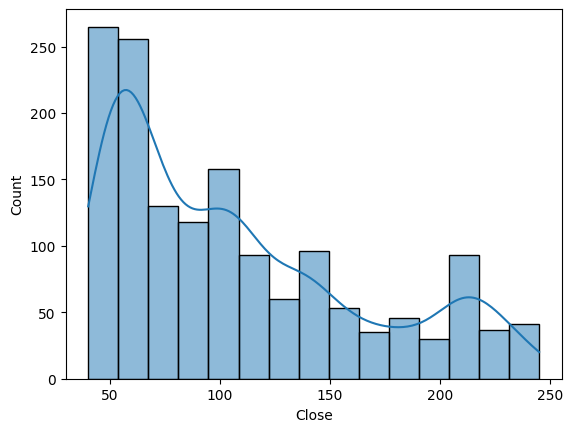

In [10]:
sns.histplot(ts['Close'], kde=True)
ts['Close'].skew()

<Axes: xlabel='Close'>

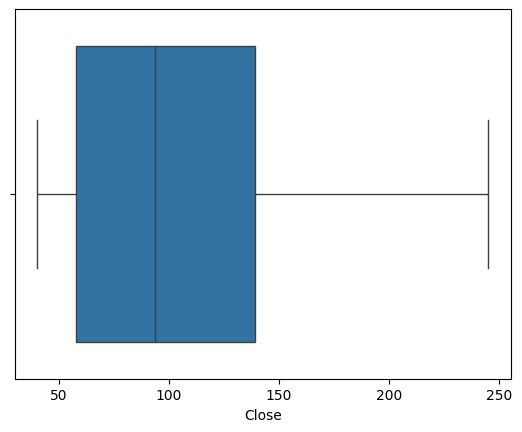

In [11]:
sns.boxplot(x=ts['Close'])

<Axes: >

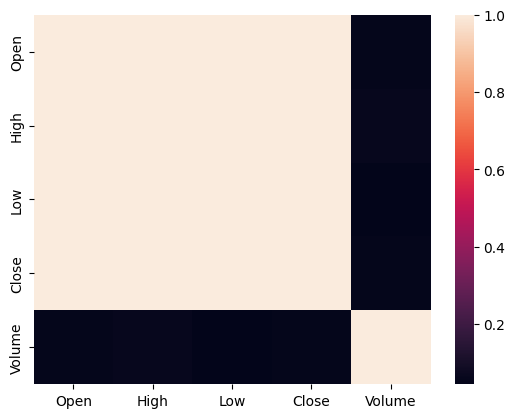

In [12]:
sns.heatmap(ts.corr(numeric_only=True))

In [15]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

def decomposition_check(feature, models):

    result = seasonal_decompose(
        ts[feature],
        model= models,
        period=30
    )

    trend = result.trend
    seasonal = result.seasonal
    residual = result.resid

    plt.figure(figsize=(12,8))

    plt.subplot(411)
    plt.plot(ts[feature], label='Original')
    plt.legend(loc='best')

    plt.subplot(412)
    plt.plot(trend, label='Trend')
    plt.legend(loc='best')

    plt.subplot(413)
    plt.plot(seasonal, label='Seasonal')
    plt.legend(loc='best')

    plt.subplot(414)
    plt.plot(residual, label='Residual')
    plt.legend(loc='best')

    plt.tight_layout()
    plt.show()

In [16]:
ts.head()

,Open,High,Low,Close,Volume
Date,,,,,
2015-04-01 16:00:00,40.60,40.76,40.31,40.72,36865322
2015-04-02 16:00:00,40.66,40.74,40.12,40.29,37487476
2015-04-06 16:00:00,40.34,41.78,40.18,41.55,39223692
2015-04-07 16:00:00,41.61,41.91,41.31,41.53,28809375
2015-04-08 16:00:00,41.48,41.69,41.04,41.42,24753438


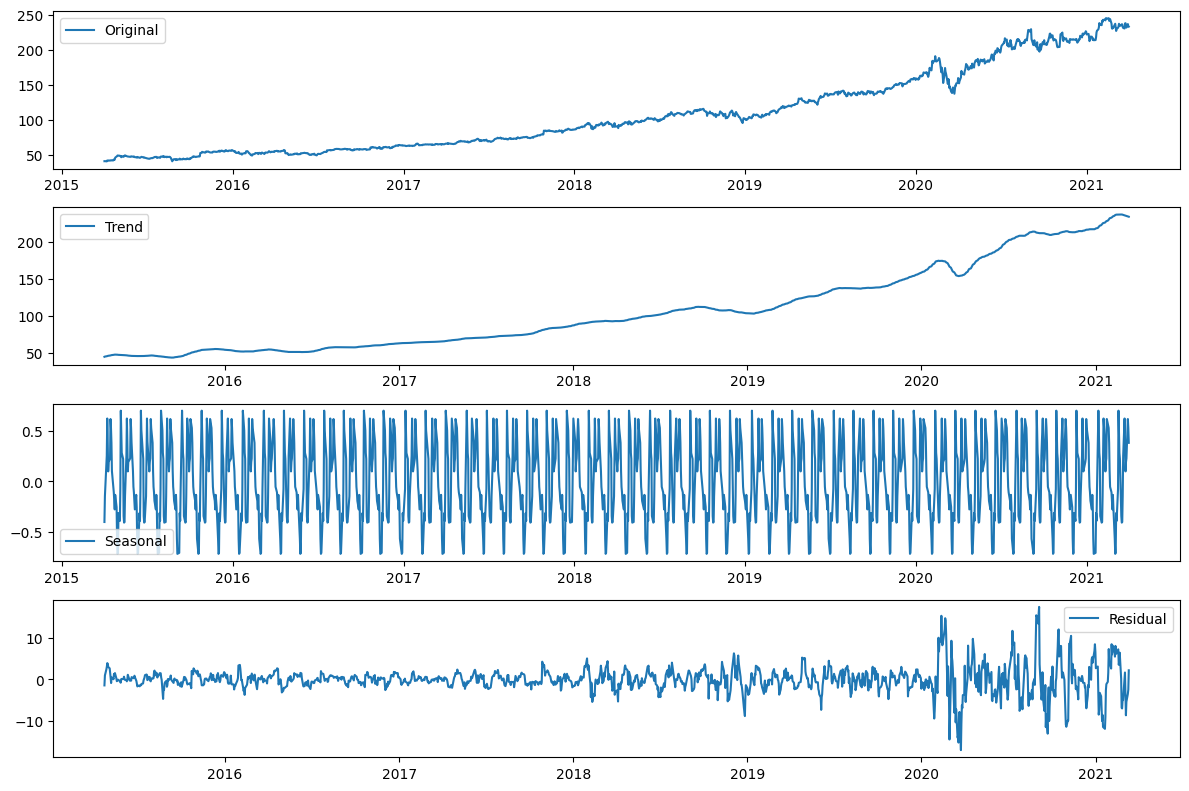

In [17]:
decomposition_check('Open', 'additive')

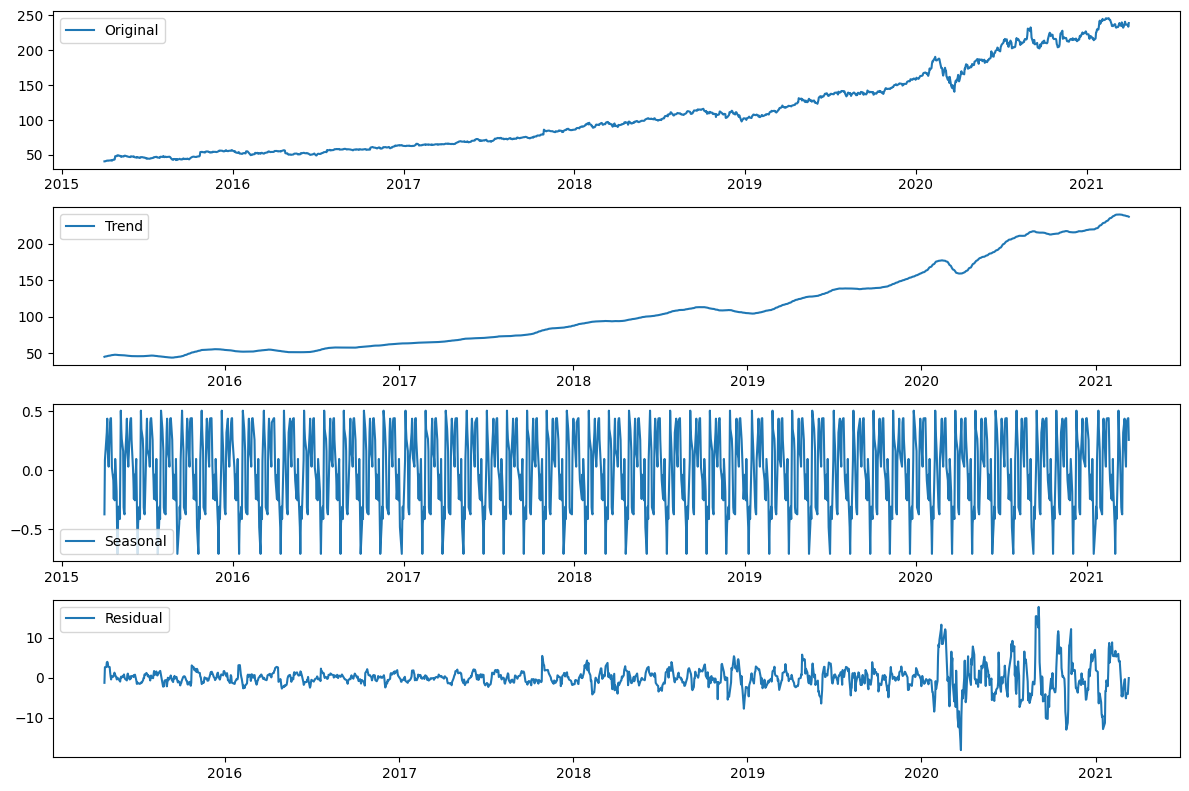

In [18]:
decomposition_check('High', 'additive')

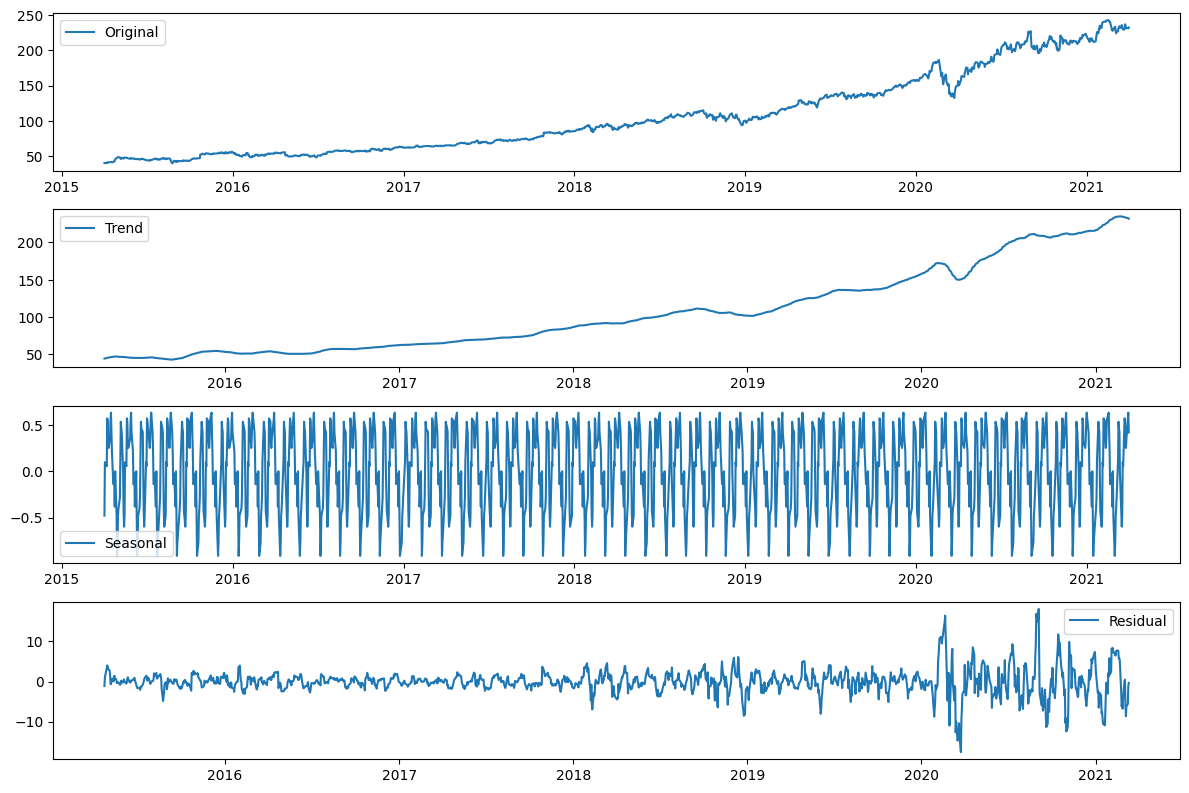

In [19]:
decomposition_check('Low', 'additive')

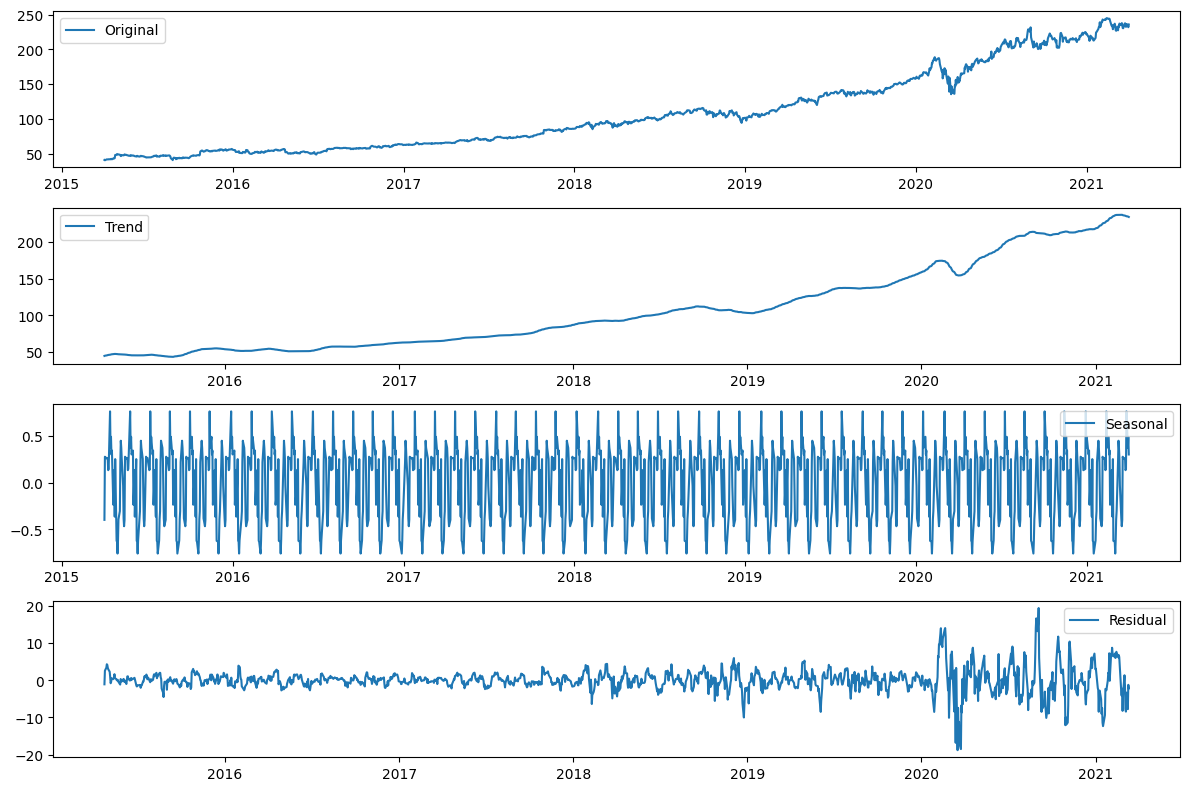

In [20]:
decomposition_check('Close', 'additive')

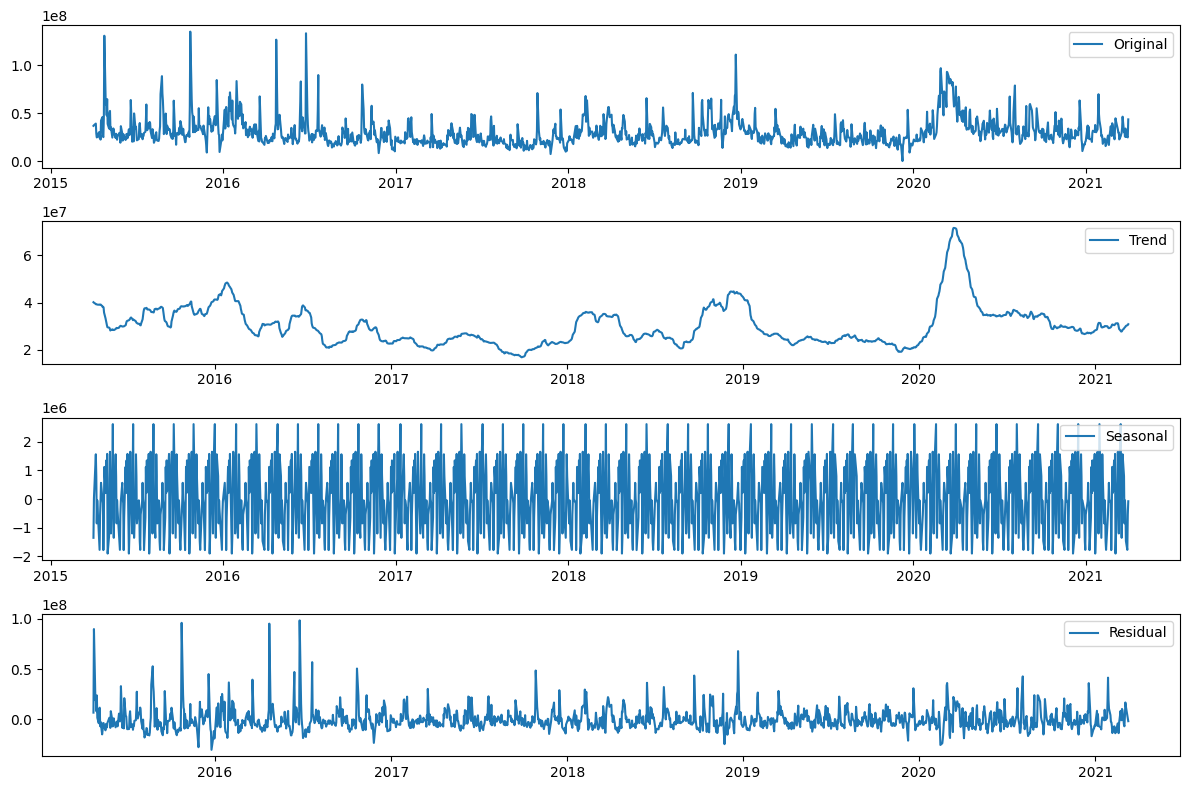

In [21]:
decomposition_check('Volume', 'additive')

In [22]:
# Stationarity Check
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['Close'])

print('ADF Statistic: ', result[0])
print('p-value: ', result[1])

for key, value in result[4].items():
    print(f"Critical Value ({key}): {value}")

ADF Statistic:  1.7371362899270957
p-value:  0.9982158366942122
Critical Value (1%): -3.4347582315402434
Critical Value (5%): -2.863486949792871
Critical Value (10%): -2.567806534528638


In [82]:
result

(np.float64(1.7371362899270957),
 np.float64(0.9982158366942122),
 24,
 1486,
 {'1%': np.float64(-3.4347582315402434),
  '5%': np.float64(-2.863486949792871),
  '10%': np.float64(-2.567806534528638)},
 np.float64(6604.225695235948))

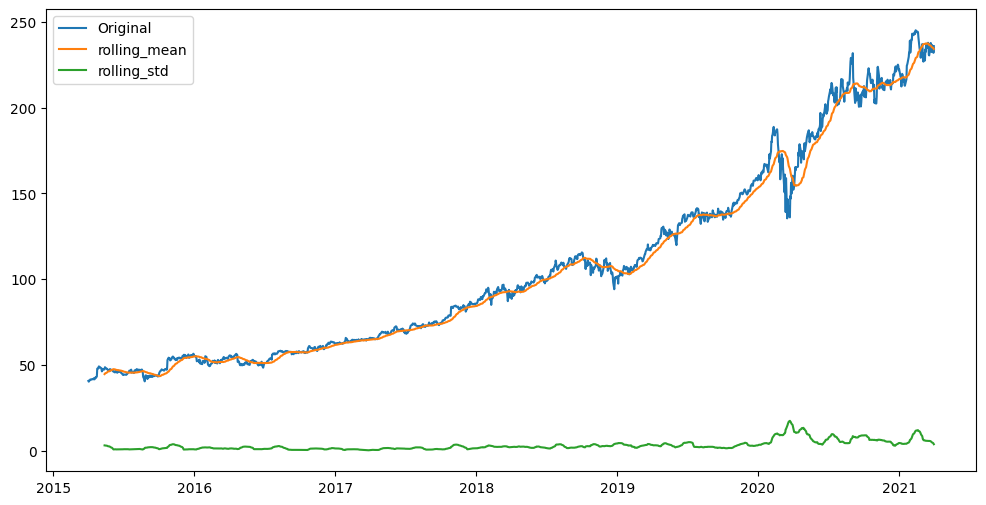

In [83]:
rolling_mean = ts['Close'].rolling(window = 30).mean()
rolling_std = ts['Close'].rolling(window = 30).std()

plt.figure(figsize = (12, 6))
plt.plot(ts['Close'], label = 'Original')
plt.plot(rolling_mean, label = 'rolling_mean')
plt.plot(rolling_std, label = 'rolling_std')
plt.legend()
plt.show()

In [84]:
ts['Close_diff'] = ts['Close'].diff()

In [85]:
ts = ts.dropna()

In [86]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['Close_diff'])
print('p-value: ', result[1])

p-value:  1.5195939917531174e-17


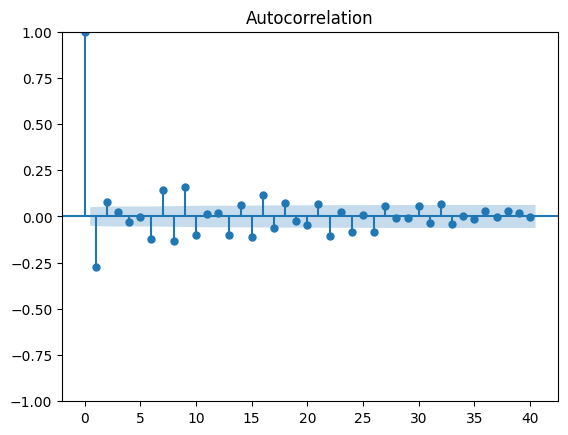

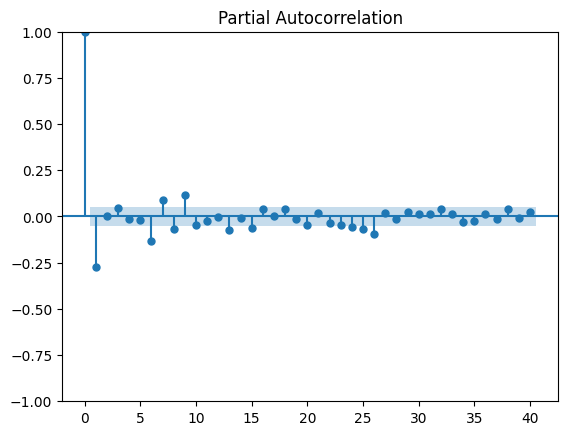

In [87]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(ts['Close_diff'], lags = 40)
plt.show()

plot_pacf(ts['Close_diff'], lags=40)
plt.show()

In [88]:
# Train test Split
train_size = int(len(ts) * 0.8)

train = ts['Close'][:train_size]
test = ts['Close'][train_size:]

In [46]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train)
predictions = []

for t in range(len(test)):

    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    history.append(test.iloc[t])

In [49]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 4.492015551477042


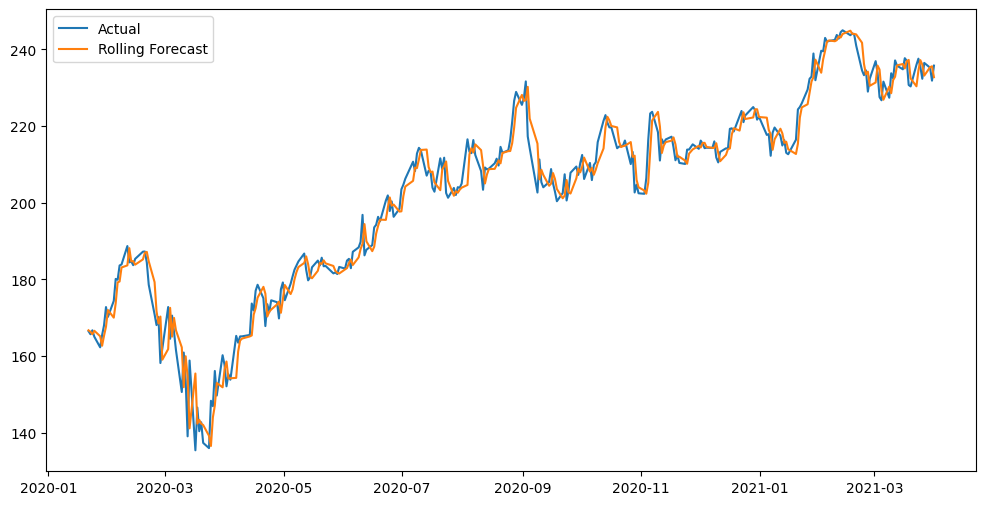

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Rolling Forecast')
plt.legend()
plt.show()

In [ ]:
(0,1,1)
(1,1,0)
(1,1,1)
(2,1,1)
(1,1,2)

In [53]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train)
predictions1 = []

for t in range(len(test)):

    model1 = ARIMA(history, order=(0,1,1))
    model_fit1 = model1.fit()

    yhat1 = model_fit1.forecast()[0]
    predictions1.append(yhat1)

    history.append(test.iloc[t])

In [89]:
rmse1 = np.sqrt(mean_squared_error(test, predictions1))
print("RMSE:", rmse1)

RMSE: 4.48415158077536


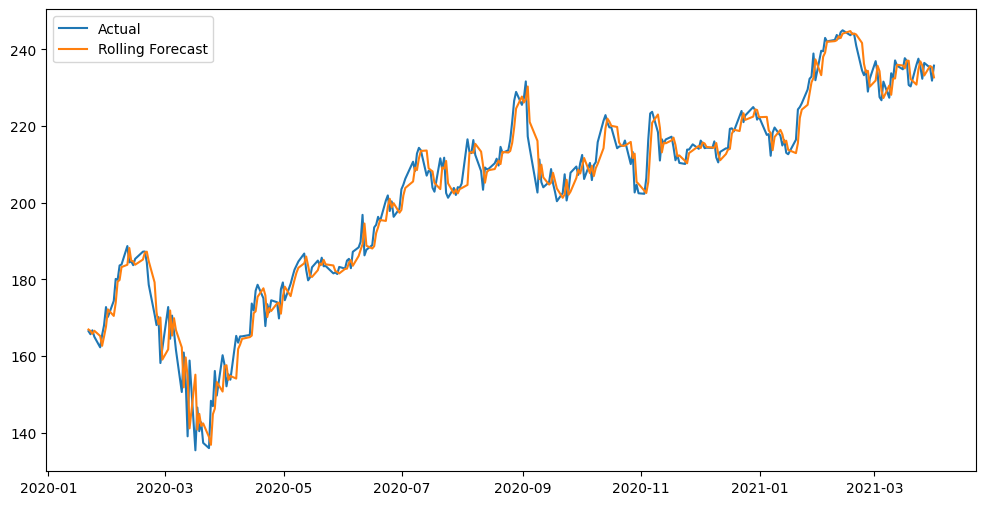

In [91]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions1, label='Rolling Forecast')
plt.legend()
plt.show()

In [56]:
history = list(train)
predictions2 = []

for t in range(len(test)):

    model2 = ARIMA(history, order=(1,1,0))
    model_fit2 = model2.fit()

    yhat2 = model_fit2.forecast()[0]
    predictions2.append(yhat2)

    history.append(test.iloc[t])

In [90]:
rmse2 = np.sqrt(mean_squared_error(test, predictions2))
print("RMSE:", rmse2)

RMSE: 4.4709237022062585


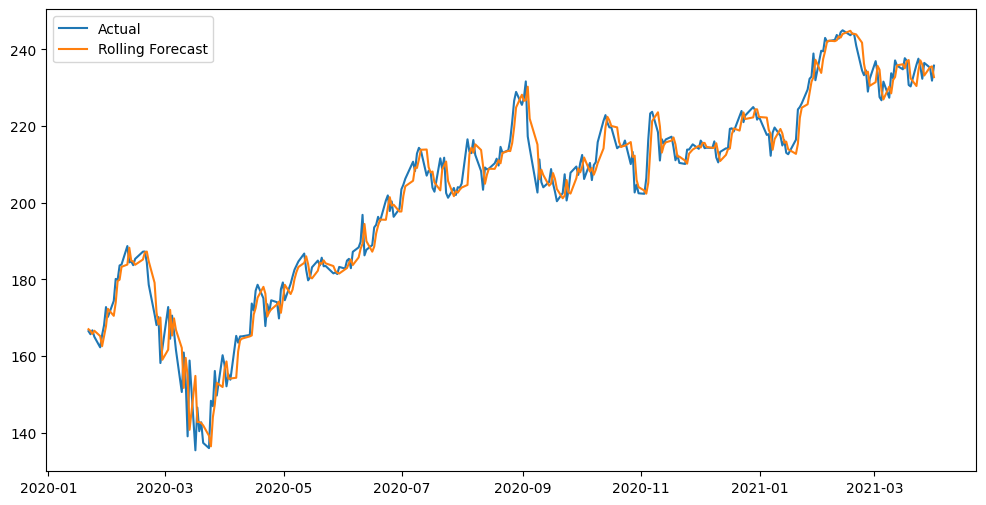

In [92]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions2, label='Rolling Forecast')
plt.legend()
plt.show()

In [98]:
history = list(train)
predictions4 = []

for t in range(len(test)):

    model4 = ARIMA(history, order=(1,1,1))
    model_fit4 = model4.fit()

    yhat4 = model_fit4.forecast()[0]
    predictions4.append(yhat4)

    history.append(test.iloc[t])

In [94]:
rmse4 = np.sqrt(mean_squared_error(test, predictions4))
print("RMSE:", rmse4)

RMSE: 39.70750719633743


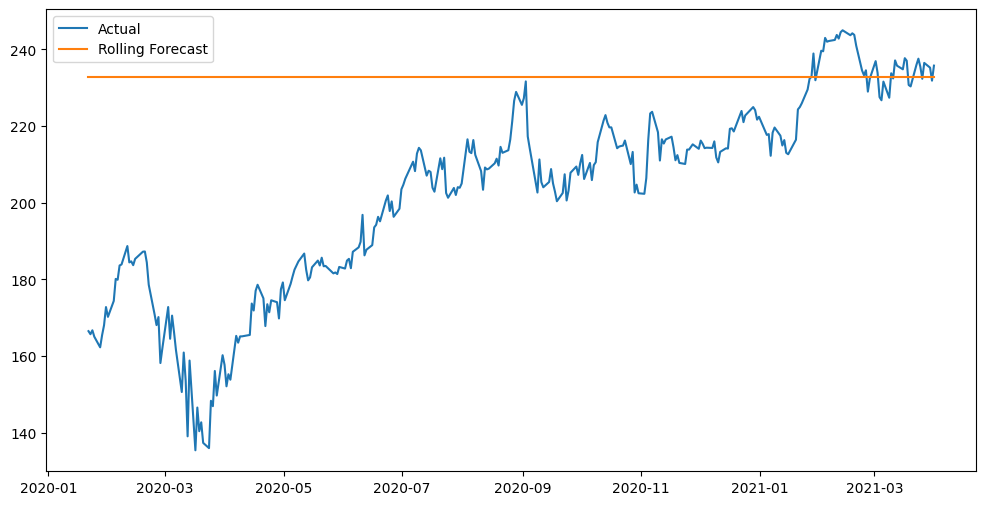

In [95]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions4, label='Rolling Forecast')
plt.legend()
plt.show()

In [97]:
print(model_fit.aic)
print(model_fit1.aic)
print(model_fit2.aic)
print(model_fit4.aic)

6759.485787534139
6768.507569597261
6757.55557142066
6768.507569597261


MODEL_fit 2 is best performing model

In [100]:
future_values = model_fit2.forecast(30)

In [101]:
future_values

array([232.76460448, 232.51784892, 232.5844223 , 232.56646114,
       232.57130697, 232.56999959, 232.57035231, 232.57025715,
       232.57028283, 232.5702759 , 232.57027777, 232.57027726,
       232.5702774 , 232.57027736, 232.57027737, 232.57027737,
       232.57027737, 232.57027737, 232.57027737, 232.57027737,
       232.57027737, 232.57027737, 232.57027737, 232.57027737,
       232.57027737, 232.57027737, 232.57027737, 232.57027737,
       232.57027737, 232.57027737])